In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [18]:
class BMIState(TypedDict):
    weight_kg: float  # in kilograms
    height_m: float  # in meters
    bmi: float     # Body Mass Index
    category: str  # BMI Category


In [20]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

In [21]:
def check_bmi_category(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [22]:
#define the state graph
graph = StateGraph(BMIState)
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('check_bmi_category', check_bmi_category)  # Placeholder for future expansion


In [23]:
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'check_bmi_category')
graph.add_edge('check_bmi_category', END)

In [24]:
workflow = graph.compile()

In [25]:
initial_state = {'weight_kg': 70, 'height_m': 1.75}
final_state = workflow.invoke(initial_state)

In [26]:
print(final_state)  # Expected to include the calculated BMI

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


## Final State Output

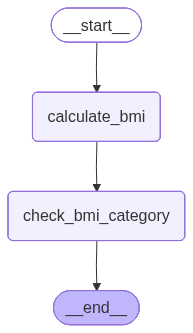

In [27]:
from IPython.display import display, Markdown, Image
display(Markdown("## Final State Output"))
Image(workflow.get_graph().draw_mermaid_png())